In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/processed/all_sales.csv")

df.head()

,date,sku,item_name,unit_upc,case_upc,quantity,unit_price,total_sales
0,2024-01-02,13353,Natural Light 2x 15 Pack (12 oz Cans),18200000317,18200200779,5,20.35,101.75
1,2024-01-02,15032,Michelob Ultra Infusions Lime and Prickly Pear...,18200007941,18200200199,1,31.50,31.50
2,2024-01-02,15800,Budweiser 30 Pack (12 oz Cans),18200000164,18200110306,1,29.00,29.00
3,2024-01-02,17100,Natural Light 30 Pack (12 oz Cans),18200000317,18200150302,1,21.15,21.15
4,2024-01-02,18048,Michelob Ultra 15 Pack (25 oz Cans),18200250101,18200960116,1,39.75,39.75


In [3]:
df.shape

(2620, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2620 entries, 0 to 2619
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         2620 non-null   str    
 1   sku          2620 non-null   int64  
 2   item_name    2620 non-null   str    
 3   unit_upc     2620 non-null   int64  
 4   case_upc     2620 non-null   int64  
 5   quantity     2620 non-null   int64  
 6   unit_price   2620 non-null   float64
 7   total_sales  2620 non-null   float64
dtypes: float64(2), int64(4), str(2)
memory usage: 163.9 KB


In [5]:
df.describe()

,sku,unit_upc,case_upc,quantity,unit_price,total_sales
count,2620.000000,2.620000e+03,2.620000e+03,2620.000000,2620.000000,2620.000000
mean,22258.440458,3.681090e+10,8.022759e+10,2.305725,28.487874,61.509882
std,8912.872077,1.157086e+11,9.396295e+11,2.129101,6.678846,52.860980
min,11300.000000,1.820000e+10,1.820011e+10,-7.000000,16.650000,-165.900000
25%,16000.000000,1.820000e+10,1.820037e+10,1.000000,22.010000,31.100000
50%,18900.000000,1.820000e+10,1.820054e+10,2.000000,30.000000,42.300000
75%,25106.000000,1.820001e+10,1.820096e+10,3.000000,32.700000,70.500000
max,48720.000000,8.511330e+11,2.085005e+13,15.000000,43.150000,421.500000


In [6]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [7]:
df.isnull().sum()

date           0
sku            0
item_name      0
unit_upc       0
case_upc       0
quantity       0
unit_price     0
total_sales    0
dtype: int64

In [8]:
print("Rows:", len(df))
print("Unique SKUs:", df["sku"].nunique())
print("Date range:", df["date"].min(), "→", df["date"].max())

Rows: 2620
Unique SKUs: 98
Date range: 2024-01-02 00:00:00 → 2026-03-17 00:00:00


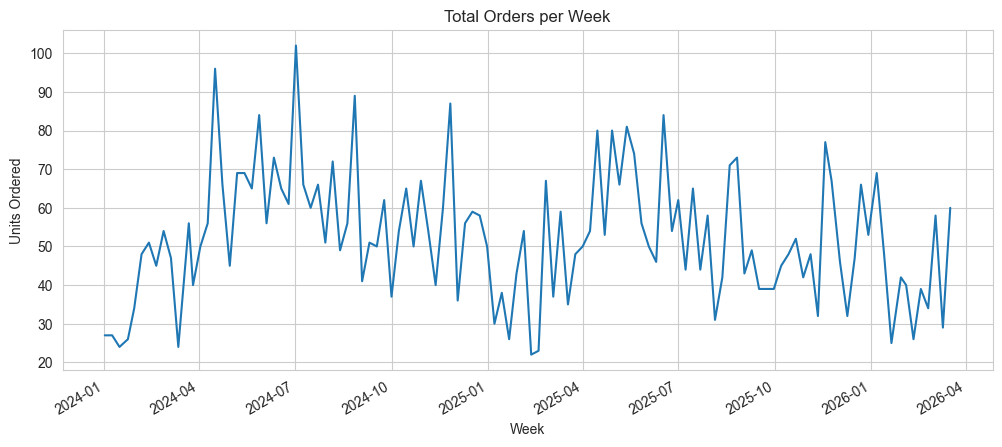

In [9]:
weekly_orders = df.groupby("date")["quantity"].sum()

plt.figure(figsize = (12, 5))
weekly_orders.plot()
plt.title("Total Orders per Week")
plt.xlabel("Week")
plt.ylabel("Units Ordered")
plt.show()

In [10]:
top_products = (
    df.groupby("item_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

item_name
Michelob Ultra 24 Pack (12 oz Cans)       656
Bud Light 18 Pack (12 oz Cans)            559
Michelob Ultra 2x 12 Pack (12 oz Cans)    478
Bud Light 20 Pack (12 oz Bottles)         442
Michelob Ultra 18 Pack (12 oz Cans)       370
Bud Light 2x 12 Pack (12 oz Cans)         266
Bud Light 3x 8 Pack (16 oz Cans)          245
Bud Light 6x 4 Pack (16 oz Cans)          241
Natural Light 2x 15 Pack (12 oz Cans)     220
Bud Light 30 Pack (12 oz Cans)            215
Name: quantity, dtype: int64

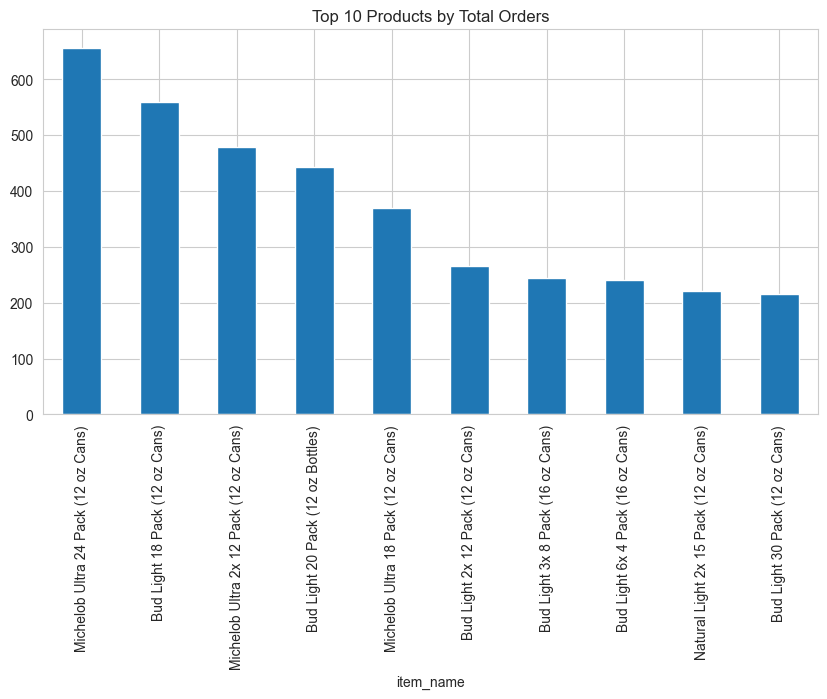

In [11]:
top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Total Orders")
plt.show()

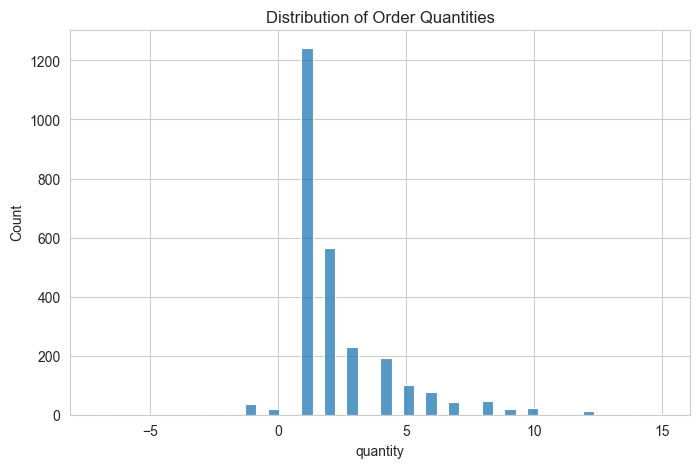

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["quantity"], bins=50)
plt.title("Distribution of Order Quantities")
plt.show()

In [13]:
weekly_orders_product = (
    df.groupby(["date", "item_name"])["quantity"]
    .sum()
    .reset_index()
)

weekly_orders_product.head()

,date,item_name,quantity
0,2024-01-02,Bud Light 20 Pack (12 oz Bottles),6
1,2024-01-02,Bud Light 3x 8 Pack (16 oz Cans),1
2,2024-01-02,Bud Light 6x 4 Pack (16 oz Cans),1
3,2024-01-02,Budweiser 30 Pack (12 oz Cans),1
4,2024-01-02,Budweiser Chelada with Clamato 15 Pack (25 oz ...,1


In [14]:
example_product = weekly_orders_product["product_name"].iloc[0]

product_df = weekly_orders_product[
    weekly_orders_product["product_name"] == example_product
]

plt.figure(figsize=(12,5))
plt.plot(product_df["date"], product_df["quantity"])
plt.title(f"Weekly Orders for {example_product}")
plt.xlabel("Week")
plt.ylabel("Units Ordered")
plt.show()

KeyError: 'product_name'

In [15]:
df["quantity"].describe()

count    2620.000000
mean        2.305725
std         2.129101
min        -7.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: quantity, dtype: float64

In [16]:
order_counts = df["item_name"].value_counts()

order_counts.head(10)

item_name
Michelob Ultra 24 Pack (12 oz Cans)          106
Michelob Ultra 2x 12 Pack (12 oz Cans)       105
Bud Light 6x 4 Pack (16 oz Cans)             103
Bud Light 18 Pack (12 oz Cans)               101
Bud Light 3x 8 Pack (16 oz Cans)              98
Bud Light 20 Pack (12 oz Bottles)             91
Natural Light 2x 15 Pack (12 oz Cans)         86
Michelob Ultra 18 Pack (12 oz Cans)           82
Michelob Ultra 2x 12 Pack (12 oz Bottles)     81
Bud Light 2x 12 Pack (12 oz Cans)             79
Name: count, dtype: int64

In [17]:
df_sorted = df.sort_values(["item_name", "date"])

df_sorted["days_between_orders"] = (
    df_sorted.groupby("item_name")["date"]
    .diff()
    .dt.days
)

df_sorted["days_between_orders"].describe()

count    2522.000000
mean       18.011102
std        26.435027
min         0.000000
25%         7.000000
50%         7.000000
75%        21.000000
max       413.000000
Name: days_between_orders, dtype: float64

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 2620 entries, 0 to 2619
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2620 non-null   datetime64[us]
 1   sku          2620 non-null   int64         
 2   item_name    2620 non-null   str           
 3   unit_upc     2620 non-null   int64         
 4   case_upc     2620 non-null   int64         
 5   quantity     2620 non-null   int64         
 6   unit_price   2620 non-null   float64       
 7   total_sales  2620 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(4), str(1)
memory usage: 184.2 KB


In [19]:
# tracking negative values as returns so model wont get cnfused
# do this by convert ot quantity_clean and tracking retunrs serperatrlry
df["is_return"] = df["quantity"] < 0
df["quantity_clean"] = df["quantity"].clip(lower=0)
df["is_return"].sum()

np.int64(41)

In [20]:
print("Original total:", df["quantity"].sum())
print("Clean total:", df["quantity_clean"].sum())

Original total: 6041
Clean total: 6099


In [44]:
weekly_df = (
    df.groupby(["date", "item_name"])["quantity_clean"]
    .sum()
    .reset_index()
)

weekly_df.head()

,date,item_name,quantity_clean
0,2024-01-02,Bud Light 20 Pack (12 oz Bottles),6
1,2024-01-02,Bud Light 3x 8 Pack (16 oz Cans),1
2,2024-01-02,Bud Light 6x 4 Pack (16 oz Cans),1
3,2024-01-02,Budweiser 30 Pack (12 oz Cans),1
4,2024-01-02,Budweiser Chelada with Clamato 15 Pack (25 oz ...,1


In [45]:
weekly_df = (
    df.groupby(["date", "item_name"])["quantity_clean"]
    .sum()
    .reset_index()
)

weekly_df.head(20)
weekly_df["quantity_clean"].describe()

count    2574.000000
mean        2.369464
std         2.105241
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        16.000000
Name: quantity_clean, dtype: float64

In [48]:
all_dates = weekly_df["date"].sort_values().unique()
all_products = weekly_df["item_name"].unique()

full_index = pd.MultiIndex.from_product(
    [all_dates, all_products],
    names=["date", "item_name"]
)

weekly_df = (weekly_df
             .set_index(["date", "item_name"])
             .reindex(full_index)
             .reset_index()
    )

weekly_df["quantity_clean"] = weekly_df["quantity_clean"].fillna(0)

In [49]:
weekly_df.to_csv("../data/processed/weekly_orders_clean.csv", index=False)

In [50]:
import os
print(os.getcwd())

/Users/sahithgondi/Downloads/beer-demand-forecasting/notebooks


In [51]:
df["quantity"].describe()

count    2620.000000
mean        2.305725
std         2.129101
min        -7.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: quantity, dtype: float64

In [52]:
df["quantity_clean"].describe()

count    2620.000000
mean        2.327863
std         2.090850
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: quantity_clean, dtype: float64